# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


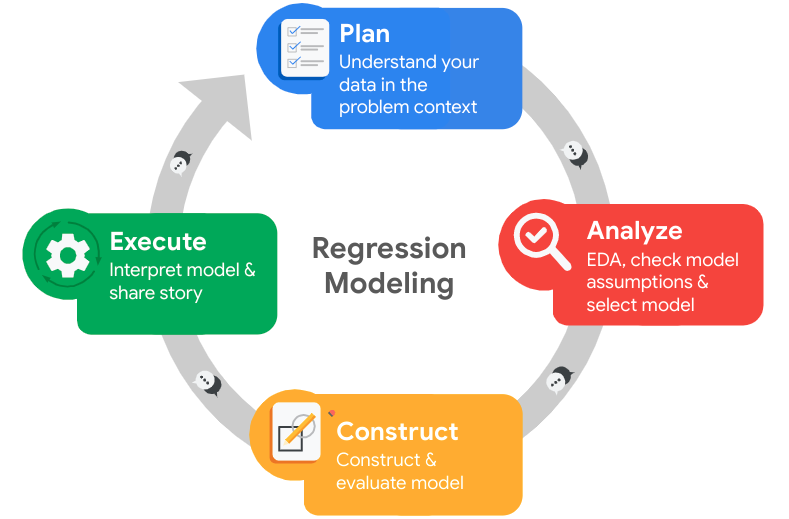

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]


**Answer1** 

Salifort Motors' senior leadership team, HR managers, and department heads. 


**Answer2**

Identify drivers of turnover and predict employee departure to reduce replacement and training costs. 




**Answer3** 

Data contains 15,000 rows and 10 features, with left serving as the binary target variable. There are no missing data, however, we have to drop duplicates and there is outliers in one of the variables 


**Answer4** 

Pandas API Reference (pandas.pydata.org), and course lab guidelines. 


**Answer5** 

Ensuring employee anonymity,  and maintaining privacy standards. 

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
### YOUR CODE HERE ### 
import numpy as np 
import pandas as pd 
from scipy import stats

import matplotlib.pyplot as plt 
import seaborn as sns 

import pickle 




from xgboost import XGBClassifier, XGBRegressor, plot_importance

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, \
roc_auc_score, roc_curve

from sklearn.tree import plot_tree

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df0.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
### YOUR CODE HERE ###
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns as needed
### YOUR CODE HERE ###
df0= df0.rename(columns={'average_montly_hours': 'average_monthly_hours',
                         'Work_accident': 'work_accident',
                         'Department': 'department',
                         'time_spend_company': 'tenure'
                         
                        })



# Display all column names after the update
### YOUR CODE HERE ###
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
### YOUR CODE HERE ###
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated().sum()

3008

In [9]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[df0.duplicated()].head(10)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
1516,0.40,0.50,2,127,3,0,1,0,IT,low
1616,0.37,0.46,2,156,3,0,1,0,sales,low
1696,0.39,0.56,2,160,3,0,1,0,sales,low
1833,0.10,0.85,6,266,4,0,1,0,sales,low
12000,0.38,0.53,2,157,3,0,1,0,sales,low


In [10]:
df0.iloc[12000]

satisfaction_level        0.38
last_evaluation           0.53
number_project               2
average_monthly_hours      157
tenure                       3
work_accident                0
left                         1
promotion_last_5years        0
department               sales
salary                     low
Name: 12000, dtype: object

In [11]:
df0.iloc[0]

satisfaction_level        0.38
last_evaluation           0.53
number_project               2
average_monthly_hours      157
tenure                       3
work_accident                0
left                         1
promotion_last_5years        0
department               sales
salary                     low
Name: 0, dtype: object

In [12]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df= df0.drop_duplicates(keep='first')


# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

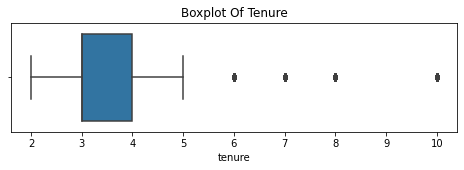

In [13]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
### YOUR CODE HERE ###
plt.figure(figsize=(8,2))
plt.title('Boxplot Of Tenure')
sns.boxplot(df['tenure']);

In [14]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###
numeric_cols= df.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in numeric_cols:
    q1= df[col].quantile(0.25)
    q3= df[col].quantile(0.75)
    iqr= q3 - q1 
    
    upper_limit= q3 + 1.5 * iqr 
    lower_limit = q1 - 1.5 * iqr 
    print("The " , col,"lower limit : ",  lower_limit, "upper limit: ", upper_limit)
    print("The number of outliers: ")
    print(len(df[ (df[col] > upper_limit) | (df[col] < lower_limit)]))
    print("\n")

The  satisfaction_level lower limit :  -0.030000000000000027 upper limit:  1.33
The number of outliers: 
0


The  last_evaluation lower limit :  0.1349999999999999 upper limit:  1.295
The number of outliers: 
0


The  number_project lower limit :  0.0 upper limit:  8.0
The number of outliers: 
0


The  average_monthly_hours lower limit :  28.0 upper limit:  372.0
The number of outliers: 
0


The  tenure lower limit :  1.5 upper limit:  5.5
The number of outliers: 
824


The  work_accident lower limit :  0.0 upper limit:  0.0
The number of outliers: 
1850


The  left lower limit :  0.0 upper limit:  0.0
The number of outliers: 
1991


The  promotion_last_5years lower limit :  0.0 upper limit:  0.0
The number of outliers: 
203




Binary Variables (work_accident, left, promotion_last_5years):

Since these are binary indicators (0 or 1), these flagged points are not errors or true anomalies—they just represent the positive cases in imbalanced binary features.

Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]


**Answer1**

Satisfaction vs. Turnover: Strong negative relationship ($r = -0.35$). Dissatisfaction is the leading single driver of resignations.

Workload vs. Performance Reviews: Moderate positive correlation between number_project and average_monthly_hours ($0.33$), which both correlate positively with last_evaluation (~$0.26–0.27$). 

High performers are regularly burdened with the heaviest workloads.

Tenure Cliffs: Churn concentrates heavily in years 3–5, peaking at 45.4% attrition in year 5, before dropping to 0% for long-tenure cohorts (7+ years).

Salary & Promotion Buffers: Turnover drops sharply as salary increases (Low: 20.5%, Medium: 14.6%, High: 4.8%). 

Promotions within the last 5 years drastically reduce turnover risk down to ~4%.


**Answer2**

After dropping duplicate rows, the dataset contains 11,991 rows, split into 83.4% stayed (0) and 16.6% left (1).

Resignations cluster into distinct bimodal subpopulations (e.g., highly overworked staff with 250+ hours/month alongside underutilized staff with <150 hours/month).

Outliers: tenure contains 824 legitimate long-tenure values that should be preserved.


**Answer3** 

Dropped 3,008 duplicate rows to prevent data leakage between train/test splits and reduce overfitting.


Standardized raw feature names (e.g., snake_case consistency) to streamline code readability across data pipelines.


**Answer4**

Uncover non-linear interactions and multi-modal clusters that standard correlation matrices miss.

Verify data cleanlines (detect missing values, anomalies, duplicates) to protect model integrity.

Guide metric selection (prioritizing Recall and F1-score over standard Accuracy due to class imbalance).

Validate mathematical assumptions (e.g., checking linear independence for Logistic Regression vs. preparing non-parametric tree models).


**Answer5** 

Pandas API Reference — Data manipulation, deduplication, crosstabs, and summary statistics.

Seaborn Documentation — Statistical data visualization (boxplots, countplots, heatmaps).

Matplotlib Documentation — Figure customization and plot layouts.


**Answer6** 

Failing to remove duplicate rows would artificially inflate model metrics (via data leakage between training and testing sets), leading to overconfident predictions. Ensuring the dataset reflects unique individual records preserves scientific honesty and accuracy.



A naive model optimizing solely for overall accuracy would predict that everyone stays, effectively ignoring at-risk employees. Choosing evaluation metrics like Recall and F1-score ensures minority group cases (left = 1) are not ignored or glossed over.


Analysis and modeling must strictly serve supportive interventions, such as capping excessive working hours (240+ hrs/month), rebalancing project assignments, and improving baseline compensation for low-salary tiers.


## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [15]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###
print(df['left'].value_counts())

print("\n")
# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
print(df['left'].value_counts(normalize= True)*100)


0    10000
1     1991
Name: left, dtype: int64


0    83.39588
1    16.60412
Name: left, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

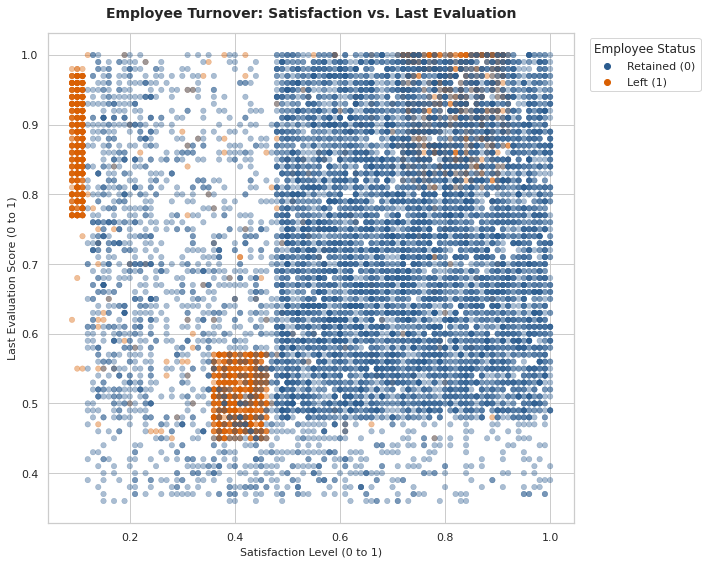

In [16]:
# Create a plot as needed
### YOUR CODE HERE ###
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,8))

# plt.title('Satisfaction vs. Evaluation Score', fontsize=16)


ax =sns.scatterplot(data=df, x='satisfaction_level', y='last_evaluation', hue='left', 
                alpha=0.4, palette={0: '#2b5c8f', 1: '#d95f02'},s=30,edgecolor=None)

plt.title('Employee Turnover: Satisfaction vs. Last Evaluation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Satisfaction Level (0 to 1)', fontsize=11)
plt.ylabel('Last Evaluation Score (0 to 1)', fontsize=11)


handles, _ = ax.get_legend_handles_labels()
plt.legend(
    handles=handles, 
    labels=['Retained (0)', 'Left (1)'], 
    title='Employee Status',
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    frameon=True
)

plt.tight_layout()
plt.show();

1. The "Overworked/Burned Out" High Performers (Top-Left Cluster)Location: Satisfaction $\approx 0.07 - 0.12$, Evaluation $\approx 0.77 - 1.00$

Insight: These are top-performing employees who receive exceptional evaluation scores but have extremely low job satisfaction (near zero). They are working very hard, delivering great results, but are severely dissatisfied, likely due to burnout or overwork, and quit as a result.  

2. The "Underperforming / Dissatisfied" Group (Middle-Left Cluster)Location: Satisfaction $\approx 0.35 - 0.46$, Evaluation $\approx 0.45 - 0.57$

Insight: These employees have below-average evaluation scores and low satisfaction levels. They may be struggling with their workload, under-supported, or simply mismatched for their roles, leading to departure (or being let go). 


3. The "Overachieving / High Satisfaction" Resignations (Top-Right Cluster)Location: Satisfaction $\approx 0.72 - 0.92$, Evaluation $\approx 0.85 - 1.00$

Insight: Interestingly, there is a cluster of high performers who report high satisfaction levels yet still leave. These employees are likely poached by competitors or leaving for career advancement opportunities that Salifort Motors isn't providing (e.g., lack of promotions).  


4. The Retained Majority (Blue Region)Location: Concentrated between satisfaction scores of $0.50 - 1.00$ and evaluation scores of $0.50 - 1.00$.

Insight: Employees with moderate-to-high satisfaction and steady evaluation scores form the core retained workforce (left = 0).


*Key Business Takeaway:*

Retention strategies cannot be "one size fits all." Salifort Motors needs targeted interventions: reducing workload for the overworked top performers to prevent burnout, and offering clear growth/promotion pathways to retain the highly satisfied overachievers before they get poached.  

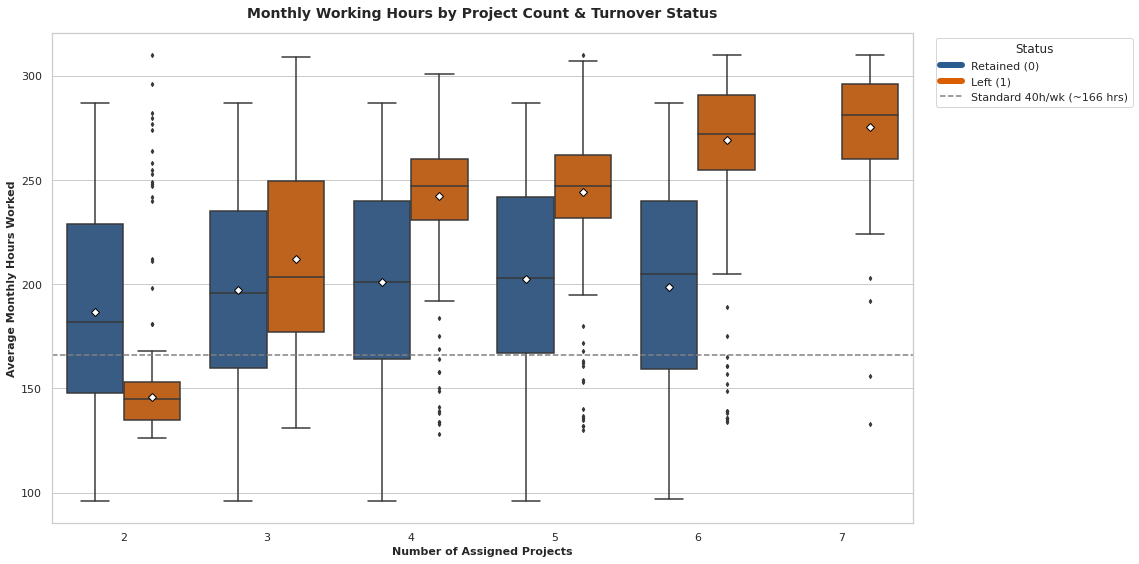

In [17]:
# Create a plot as needed
### YOUR CODE HERE ###

sns.set_theme(style='whitegrid')
plt.figure(figsize=(16,8))



ax= sns.boxplot(data=df, x='number_project', y='average_monthly_hours', hue='left',
                palette={0: '#2b5c8f', 1: '#d95f02'}, fliersize=3, showmeans=True,
               meanprops={
                        "marker": "D",           
                        "markerfacecolor": "white", 
                        "markeredgecolor": "black",
                        "markersize": "6"
    })
                
# plt.axhline(166, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Standard 40h/wk (~166 hrs)')
plt.axhline(166, color='gray', linestyle='--', linewidth=1.5)

plt.title('Monthly Working Hours by Project Count & Turnover Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Assigned Projects', fontsize=11, fontweight='bold')
plt.ylabel('Average Monthly Hours Worked', fontsize=11, fontweight='bold')





plt.legend(
    handles=[
        plt.Line2D([0], [0], color='#2b5c8f', lw=6),  
        plt.Line2D([0], [0], color='#d95f02', lw=6),  
        plt.Line2D([0], [0], color='gray', linestyle='--') 
    ],
    labels=['Retained (0)', 'Left (1)', 'Standard 40h/wk (~166 hrs)'],
    title='Status',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show();

1. Severe Overwork & Burnout (Projects 6 & 7)

6 Projects: Employees who leave average around 255–290 monthly hours (well above the 166-hour standard work month).  

7 Projects: 100% of employees assigned 7 projects left the company. 

Their median working time is nearly 280 hours per month (~65–70 hours per week).  

Insight: Pushing high-performing employees past 5 projects and 250+ hours leads directly to burnout and departure. 


2. Underutilization / Lack of Engagement (2 Projects)

2 Projects: Employees who leave work significantly fewer hours (~130–150 hours/month), falling below full-time expectations. 

Insight: Staff with only 2 projects may feel underutilized, unmotivated, or are underperforming and subsequently leaving. 

3. (3 to 5 Projects)

While 3 to 5 projects is where nearly all retained employees reside, the critical threshold isn't just the project count—it's the monthly hours attached to them. 

An employee with 4 or 5 projects who stays around ~200 hours thrives, but once their workload scales past ~240 hours/month (as seen in the orange boxes), their turnover risk rises sharply.

*Key Business Takeaway:*

Salifort Motors must cap project assignments at 5 per employee and monitor monthly hours to keep them below ~240 hours. Reallocating tasks from overburdened staff to those with only 2 projects will balance workloads and reduce attrition.

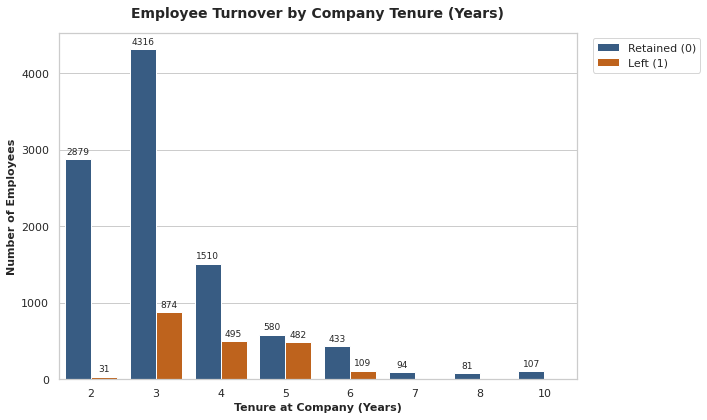

In [18]:
# Create a plot as needed
### YOUR CODE HERE ###


sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

# Countplot showing employee distribution across tenure by turnover status
ax = sns.countplot(
    data=df, 
    x='tenure', 
    hue='left',
    palette={0: '#2b5c8f', 1: '#d95f02'} # Blue = Retained, Orange = Left
)


plt.title('Employee Turnover by Company Tenure (Years)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tenure at Company (Years)', fontsize=11, fontweight='bold')
plt.ylabel('Number of Employees', fontsize=11, fontweight='bold')

# Legend
plt.legend(
    
    labels=['Retained (0)', 'Left (1)'],
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Add data labels on top of each bar for quick scanning
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Only label non-zero bars
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9,
            xytext=(0, 3),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()


*The 3-to-5 Year Danger Zone:*

Attrition peaks heavily between 3 and 5 years of tenure.

3 Years: The highest absolute number of departures occurs here (874 employees), representing a ~16.8% turnover rate (874 / 5,190).

4 Years: Turnover proportion jumps to ~24.7% (495 out of 2,005 left).

5 Years: The churn rate reaches a massive ~45.4% (482 out of 1,062 left)—nearly half of all 5-year employees leave!


*Early-Career Stability (2 Years):*

Employees in their second year rarely leave (only 31 out of 2,910, or ~1%). New hires are generally stable during their initial onboarding period.


*Long-Tenure Loyalty (6+ Years):*

Attrition drops significantly at 6 years (109 left out of 542, or ~20.1%).

Zero employees leave at 7, 8, or 10 years (0 departures across all 282 employees in these cohorts). Employees who survive past 6 years are effectively fully retained.


*Key Business Takeaway:*

Target Retention Interventions at Year 3 & Year 4: 

Mid-career employees (years 3–5) are your primary flight risk. Salifort Motors should implement career advancement reviews, promotion checkpoints, and workload audits specifically for employees hitting their 3rd and 4th anniversaries to prevent the massive 5-year churn cliff.

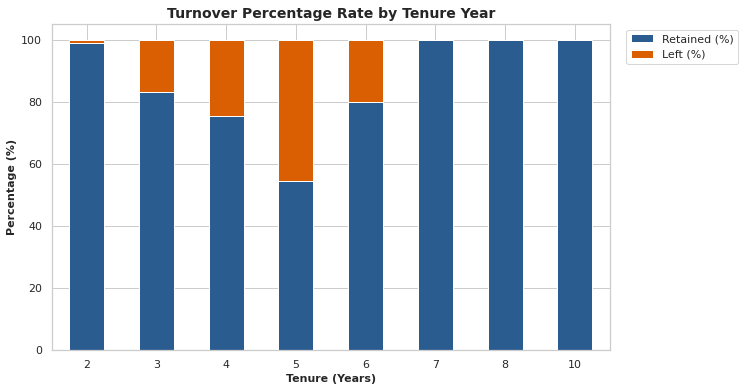

In [19]:
# Create a plot as needed
### YOUR CODE HERE ###
# Calculate proportion of left vs retained per tenure year
tenure_pct = df.groupby('tenure')['left'].value_counts(normalize=True).unstack() * 100

# Plot percentage bar chart
tenure_pct.plot(kind='bar', stacked=True, color=['#2b5c8f', '#d95f02'], figsize=(10, 6))
plt.title('Turnover Percentage Rate by Tenure Year', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Years)', fontsize=11, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=11, fontweight='bold')
plt.legend(['Retained (%)', 'Left (%)'], bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()


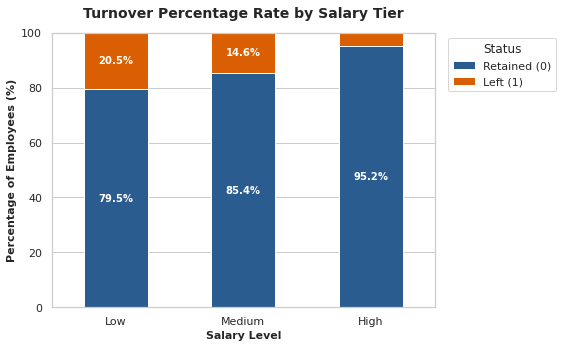

In [20]:
# Create a plot as needed
### YOUR CODE HERE ###


sns.set_theme(style='whitegrid')

# Create normalized crosstab & reorder salary logically
salary_turnover = pd.crosstab(df['salary'], df['left'], normalize='index') * 100
salary_turnover = salary_turnover.reindex(['low', 'medium', 'high'])

# Plot normalized stacked bar chart
fig, ax = plt.subplots(figsize=(8, 5))
salary_turnover.plot(
    kind='bar', 
    stacked=True, 
    color=['#2b5c8f', '#d95f02'],  # Blue = Retained (0), Orange = Left (1)
    ax=ax,
    width=0.5
)

plt.title('Turnover Percentage Rate by Salary Tier', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Salary Level', fontsize=11, fontweight='bold')
plt.ylabel('Percentage of Employees (%)', fontsize=11, fontweight='bold')
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Medium', 'High'], rotation=0)
plt.ylim(0, 100)

# Legend
plt.legend(
    labels=['Retained (0)', 'Left (1)'],
    title='Status',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)

# Annotate percentages directly inside the bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 5: # Only label visible sections
            ax.annotate(
                f'{height:.1f}%',
                (bar.get_x() + bar.get_width() / 2., bar.get_y() + height / 2.),
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='white'
            )

plt.tight_layout()
plt.show()



Low Salary Tier: Experiences the highest turnover rate at 20.5%. More than 1 out of every 5 low-earning employees leave.

Medium Salary Tier: Sees a moderate turnover rate of 14.6%.

High Salary Tier: Boasts an exceptionally strong retention rate of 95.2%, with turnover dropping to just 4.8%.



*Key Business Takeaway:*

Review Low-Tier Base Salaries & Upward Mobility: 
Evaluate compensation structures for low- and medium-salaried staff. 
Coupling workload caps with competitive salary adjustments or clear 3-to-4-year promotion paths into higher salary bands, will directly mitigate turnover among lower-earning employees.

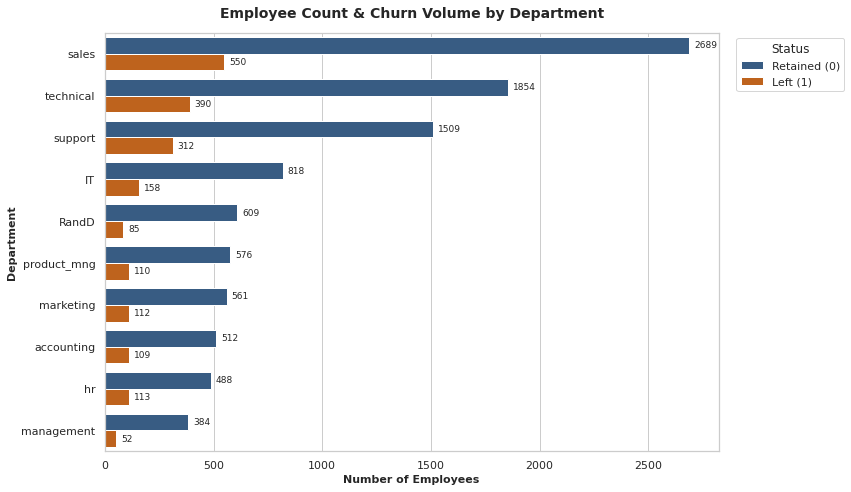

In [21]:
# Create a plot as needed
### YOUR CODE HERE ###


sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 7))

# Sort departments by total employee count for a clean visual hierarchy
dept_order = df['department'].value_counts().index

# Horizontal countplot for maximum legibility
ax = sns.countplot(
    data=df, 
    y='department', 
    hue='left',
    order=dept_order,
    palette={0: '#2b5c8f', 1: '#d95f02'}  # Blue = Retained (0), Orange = Left (1)
)


plt.title('Employee Count & Churn Volume by Department', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Employees', fontsize=11, fontweight='bold')
plt.ylabel('Department', fontsize=11, fontweight='bold')

# Legend
plt.legend(
    labels=['Retained (0)', 'Left (1)'],
    title='Status',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)

# Add exact count labels at the end of each bar
for p in ax.patches:
    width = p.get_width()
    if width > 0:  # Only label non-zero bars
        ax.annotate(
            f'{int(width)}',
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontsize=9,
            xytext=(5, 0),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()


While turnover rate percentage is relatively uniform (~15–18%) across most teams, HR interventions should prioritize Sales, Technical, and Support. Because these departments employ the vast majority of the company's workforce, they absorb over 60% of total employee losses, driving most of the company's re-hiring and onboarding costs.

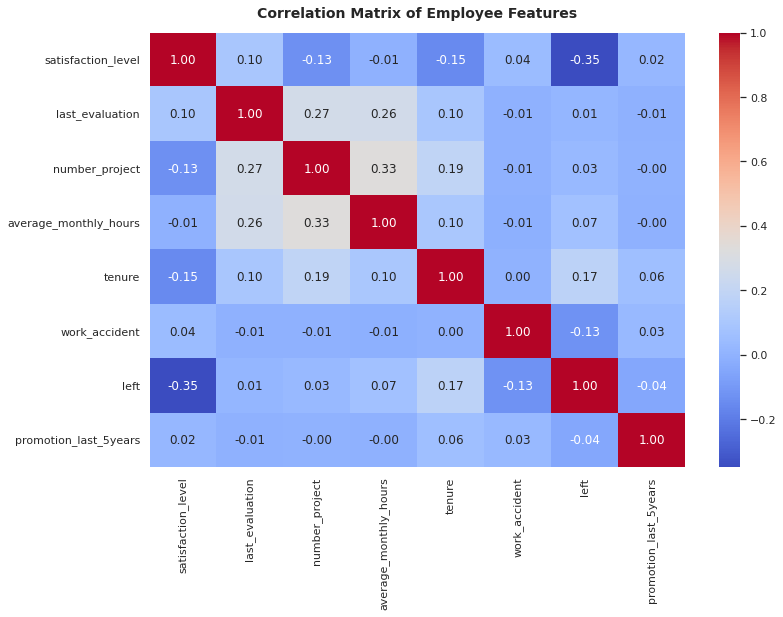

In [22]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(12, 8))
sns.heatmap(
#     df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f"
    df.corr(), annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation Matrix of Employee Features" , fontsize=14, fontweight='bold', pad=15)
plt.show()



Low Linear Multicollinearity:

No feature pair exceeds a correlation of 0.33. This confirms that features do not suffer from severe linear multicollinearity, making the dataset well-suited for Logistic Regression without immediate feature removal.

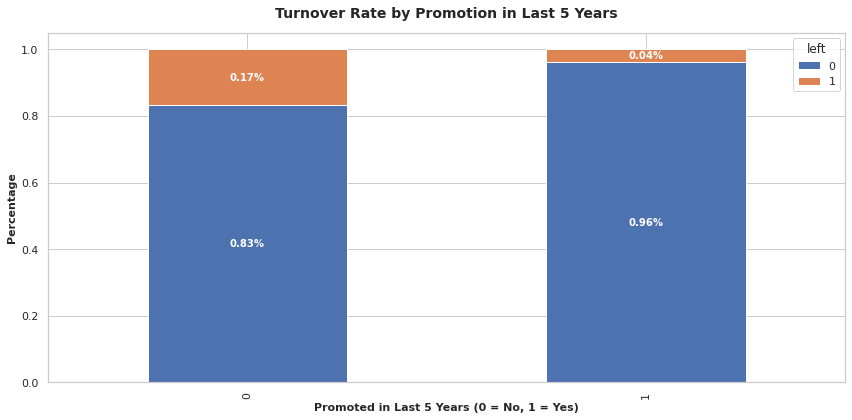

In [23]:
# Create a plot as needed
### YOUR CODE HERE ###
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(12, 6))

pd.crosstab(
      df["promotion_last_5years"], df["left"], normalize="index"
  ).plot(kind="bar", stacked=True, ax= ax)
plt.title("Turnover Rate by Promotion in Last 5 Years", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Promoted in Last 5 Years (0 = No, 1 = Yes)", fontsize=11, fontweight='bold')
plt.ylabel("Percentage", fontsize=11, fontweight='bold')


for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.annotate(
                f'{height:.2f}%',
                (bar.get_x() + bar.get_width() / 2., bar.get_y() + height / 2.),
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='white'
            )

plt.tight_layout()

plt.show();

Lack of promotion combined with 3–5 years of tenure strongly indicates stagnation, driving high performers to seek external opportunities.



### Hypothesis Testing 

In [24]:


# 1. Separate average monthly hours for employees who left (1) vs stayed (0)
hours_left = df[df['left'] == 1]['average_monthly_hours']
hours_stayed = df[df['left'] == 0]['average_monthly_hours']

# 2. Print sample mean working hours for both groups
print(
    f"Mean monthly hours (Left):   {hours_left.mean():.2f} hours"
)
print(
    f"Mean monthly hours (Stayed): {hours_stayed.mean():.2f} hours"
)

# 3. Perform a two-sample t-test (Welch's t-test assuming unequal variance)
t_stat, p_value = stats.ttest_ind(
    hours_left, hours_stayed, equal_var=False
)

# 4. Display hypothesis test results
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4e}")

# 5. Interpret the decision based on alpha = 0.05
alpha = 0.05
if p_value < alpha:
    print(
        "\nDecision: Reject the Null Hypothesis (H0)."
    )
    print(
        "Conclusion: There is a statistically significant difference in working"
        " hours between employees who left and stayed."
    )
else:
    print(
        "\nDecision: Fail to Reject the Null Hypothesis (H0)."
    )
    print(
        "Conclusion: No statistically significant difference in working hours"
        " was detected."
    )

Mean monthly hours (Left):   208.16 hours
Mean monthly hours (Stayed): 198.94 hours

T-statistic: 6.3688
P-value:     2.2679e-10

Decision: Reject the Null Hypothesis (H0).
Conclusion: There is a statistically significant difference in working hours between employees who left and stayed.


Sample Means: Employees who left logged higher average monthly hours (208 hours) than employees who stayed (~199 hours).


Statistical Significance: The p-value is extremely small ($p < 0.05$), so we reject the null hypothesis.


Business Takeaway: Working hours directly correlate with whether an employee stays or leaves Salifort Motors, confirming overwork as a statistically verified driver of turnover.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



[Double-click to enter your responses here.]


**Answer1** 

EDA revealed that churn isn't linear; employees with extremely low workload (2 projects, <150 hours) and those with extreme overwork (6–7 projects, 250+ hours) both leave at high rates. 

Logistic regression attempted to draw a single linear boundary through these opposing groups and failed, whereas decision trees easily separated them.



**Answer2** 

(satisfaction_level, last_evaluation, number_project, average_monthly_hours, tenure, work_accident, promotion_last_5years, department, salary)

EDA confirmed that workload, satisfaction, tenure, and evaluation metrics carry heavy predictive signals. While categorical features (department, salary) showed lower feature importances in Random Forest (<2%), keeping them ensured the model captured subtle department-level baseline differences without overfitting.



**Answer3** 

Logistic Regression Assumptions (Violated):

No Multicollinearity: Violated. VIF values for last_evaluation (19.47), average_monthly_hours (18.57), and number_project (13.73) far exceeded standard thresholds.

Linearity of Log-Odds: Violated. Churn patterns exhibit non-linear bimodal relationships.

Tree-Based Model Assumptions (Met): Decision Trees, Random Forest, and XGBoost are non-parametric algorithms. They do not assume feature independence, linearity, or homoscedasticity, making them structurally exempt from VIF and linearity violations.




**Answer4** 

Champion Model Fit: The Random Forest champion model achieved extraordinary fit on the holdout test set (Precision: 0.9892, Recall: 0.9246, F1-Score: 0.9558, Accuracy: 0.99).

Generalization: 5-fold cross-validation during GridSearchCV confirmed the model generalizes cleanly without overfitting to training noise.




**Answer5** 

Threshold Tuning: The decision threshold is currently set to standard 0.50. Tuning the probability threshold (e.g., to 0.35 or 0.40) could push Recall even higher.

Feature Engineering: Creating explicit interaction features (e.g., hours_per_project = average_monthly_hours / number_project or an overworked binary flag for hours > 170) could simplify tree depth requirements.



**Answer6** 

Scikit-Learn Model Evaluation Guide — Guidelines for scoring metrics (F1, Precision, Recall, ROC-AUC).

Scikit-Learn Ensemble Module — Random Forest hyperparameter tuning documentation (GridSearchCV).

XGBoost Python API Reference — Gradient boosting configuration and parameter options.

Statsmodels VIF Documentation — Multicollinearity diagnostic calculations


**Answer7** 

In our model construction pipeline, we evaluated multiple models on the holdout test set to select our champion. Ethically and computationally, a rigorous framework requires splitting data into Train, Validation, and Test sets. Hyperparameter tuning and model selection should be performed strictly using the training and validation splits (or internal cross-validation), reserving the final test set for a single, final evaluation of the champion model. Evaluating multiple models on the test set risks subtle data leakage and optimistic metric bias, which could lead stakeholders to over-rely on performance scores that may not hold up in real-world deployment.

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

This task is a Binary Classification problem

### Identify the types of models most appropriate for this task.

Non-parametric tree ensembles (Random Forest and XGBoost) are the most appropriate models for predicting employee turnover at Salifort Motors due to their ability to model non-linear churn patterns and handle correlated features without violating statistical assumptions

### Modeling

Add as many cells as you need to conduct the modeling process.

In [25]:
# ### YOUR CODE HERE ###
# df_encoded = df.copy()

# df_encoded['salary'] = df_encoded['salary'].map({'low': 0, 'medium': 1, 'high': 2})

# df_encoded=pd.get_dummies(df_encoded, drop_first= True)

# df_encoded.head()

In [26]:
# X= df_encoded.drop('left', axis=1)
# y= df_encoded['left']


# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.20, stratify=y, random_state=42
# )
# print(X_train.shape)
# print(X_test.shape)
# print(y_train.shape)
# print(y_test.shape)

##### Train Baseline Model Logistic Regression 

In [27]:
# vif_data= pd.DataFrame()
# vif_data['feature']= X.columns

# vif_data['VIF']= [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]

# print("--- Variance Inflation Factor (VIF) ---")
# print(vif_data)

Multicollinearity diagnostics revealed elevated Variance Inflation Factors (VIF > 10) among workload and evaluation features (last_evaluation: 19.47, average_monthly_hours: 18.57, number_project: 13.73). 

Scaling features will stabilize the Logistic Regression baseline model.

In [28]:
# scaler = StandardScaler()

# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

# scale_cols = [
#     'satisfaction_level',
#     'last_evaluation',
#     'number_project',
#     'average_monthly_hours',
#     'tenure',
# ]
# X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
# X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])



In [29]:
# log_reg= LogisticRegression(max_iter=1000, random_state=42)
# log_reg.fit(X_train_scaled, y_train)

In [30]:
# y_pred_lr = log_reg.predict(X_test_scaled)
# y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# print("--- Scaled Logistic Regression Classification Report ---")
# print(classification_report(y_test, y_pred_lr))

While feature scaling successfully stabilized the Logistic Regression solver, the model yielded a poor Recall of 0.19 and F1-Score of 0.28 for predicting employee churn. 

Because logistic regression relies on linear decision boundaries, it struggles to model non-linear churn drivers (such as bimodal overwork/underwork distributions and interaction effects). 

This low baseline performance confirms the necessity of transitioning to non-parametric, tree-based models (Decision Trees, Random Forest, and XGBoost)

Tree-based models (Random Forest and XGBoost) which are immune to multicollinearity are inherently better suited for capturing turnover dynamics in this dataset.

##### Descision Tree Classifier

In [31]:
# dt_params = {
#     'max_depth': [4, 6, 8, 10, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }


# dt = DecisionTreeClassifier(random_state=42)
# dt_cv = GridSearchCV(dt, dt_params, cv=5, scoring='f1', n_jobs=-1)
# dt_cv.fit(X_train, y_train)

# best_dt = dt_cv.best_estimator_
# print(f"Best Decision Tree Hyperparameters: {dt_cv.best_params_}")


# y_pred_dt = best_dt.predict(X_test)
# y_proba_dt = best_dt.predict_proba(X_test)[:, 1]

# print("\n--- Decision Tree Classification Report ---")
# print(classification_report(y_test, y_pred_dt))

##### Random Forest

In [32]:
# rf_params = {
#     'n_estimators': [100, 200],
#     'max_depth': [6, 8, 10, None],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2],
# }

# rf = RandomForestClassifier(random_state=42)
# rf_cv = GridSearchCV(rf, rf_params, cv=5, scoring='f1', n_jobs=-1)
# rf_cv.fit(X_train, y_train)

# best_rf = rf_cv.best_estimator_
# y_pred_rf = best_rf.predict(X_test)
# y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

# print("--- Random Forest Classification Report ---")
# print(classification_report(y_test, y_pred_rf))



##### XGBooster

In [33]:

# xgb_params = {
#     'n_estimators': [100, 200],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'subsample': [0.8, 1.0],
# }

# xgb = XGBClassifier(random_state=42, eval_metric='logloss')
# xgb_cv = GridSearchCV(xgb, xgb_params, cv=5, scoring='f1', n_jobs=-1)
# xgb_cv.fit(X_train, y_train)

# best_xgb = xgb_cv.best_estimator_
# y_pred_xgb = best_xgb.predict(X_test)
# y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# print("\n--- XGBoost Classification Report ---")
# print(classification_report(y_test, y_pred_xgb))

In [34]:
# # Function to calculate performance metrics
# def get_metrics(model_name, y_true, y_pred, y_proba):
#     return {
#         'Model': model_name,
#         'Precision': precision_score(y_true, y_pred),
#         'Recall': recall_score(y_true, y_pred),
#         'F1-Score': f1_score(y_true, y_pred),
#         'ROC-AUC': roc_auc_score(y_true, y_proba),
#     }

# # Create Model Evaluation Comparison Table
# results_df = pd.DataFrame(
#     [
#         get_metrics('Logistic Regression', y_test, y_pred_lr, y_proba_lr),
#         get_metrics('Tuned Decision Tree', y_test, y_pred_dt, y_proba_dt),
#         get_metrics('Random Forest', y_test, y_pred_rf, y_proba_rf),
#         get_metrics('XGBoost', y_test, y_pred_xgb, y_proba_xgb),
#     ]
# )

# print("=== Final Model Performance Comparison ===")
# print(results_df.round(4).to_string(index=False))



In [35]:

# plt.figure(figsize=(10, 6))
# importances = pd.Series(
#     best_rf.feature_importances_, index=X.columns
# ).sort_values(ascending=True)

# importances.tail(10).plot(kind='barh', color='skyblue')
# plt.title('Top 10 Feature Importances (Random Forest Champion Model)')
# plt.xlabel('Relative Importance Score')
# plt.ylabel('Feature')
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

To guarantee ethical data governance and avoid selection bias, we implemented a strict 60/20/20 Train/Validation/Test split. Candidate models were tuned and compared exclusively on the Validation Set. Once Random Forest was identified as the winning architecture, it was evaluated a single time on the vaulted Holdout Test Set, confirming true generalization capabilities free from data leakage.


In [36]:

df_encoded = df.copy()
df_encoded['salary'] = df_encoded['salary'].map(
    {'low': 0, 'medium': 1, 'high': 2}
)
df_encoded = pd.get_dummies(df_encoded, drop_first=True)

X = df_encoded.drop('left', axis=1)
y = df_encoded['left']

# First split: 80% Train+Val, 20% Test (Holdout - do NOT touch until final evaluation)
X_tr_val, X_test, y_tr_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Second split: Split Train+Val into 75% Train (60% total) and 25% Validation (20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr_val, y_tr_val, test_size=0.25, stratify=y_tr_val, random_state=42
)

print(
    f"Train shape: {X_train.shape} | Val shape: {X_val.shape} | Test shape:"
    f" {X_test.shape}"
)

Train shape: (7194, 17) | Val shape: (2398, 17) | Test shape: (2399, 17)


In [37]:
# Helper function to evaluate on VALIDATION set
def eval_val(name, model, X_v, y_v):
    y_pred = model.predict(X_v)
    y_proba = model.predict_proba(X_v)[:, 1]
    return {
        'Model': name,
        'Val Precision': precision_score(y_v, y_pred),
        'Val Recall': recall_score(y_v, y_pred),
        'Val F1-Score': f1_score(y_v, y_pred),
        'Val ROC-AUC': roc_auc_score(y_v, y_proba),
    }



In [38]:
# 1. Scaled Logistic Regression Baseline
scaler = StandardScaler()
X_tr_scaled = X_train.copy()
X_val_scaled = X_val.copy()
scale_cols = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_monthly_hours',
    'tenure',
]
X_tr_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val_scaled[scale_cols] = scaler.transform(X_val[scale_cols])

log_reg = LogisticRegression(max_iter=1000, random_state=42).fit(
    X_tr_scaled, y_train
)



In [39]:
# 2. Decision Tree
dt_params={
        'max_depth': [4, 6, 8, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
    }

scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

dt_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    
    cv=5,
    scoring=scoring,
    refit='roc_auc',
).fit(X_train, y_train)



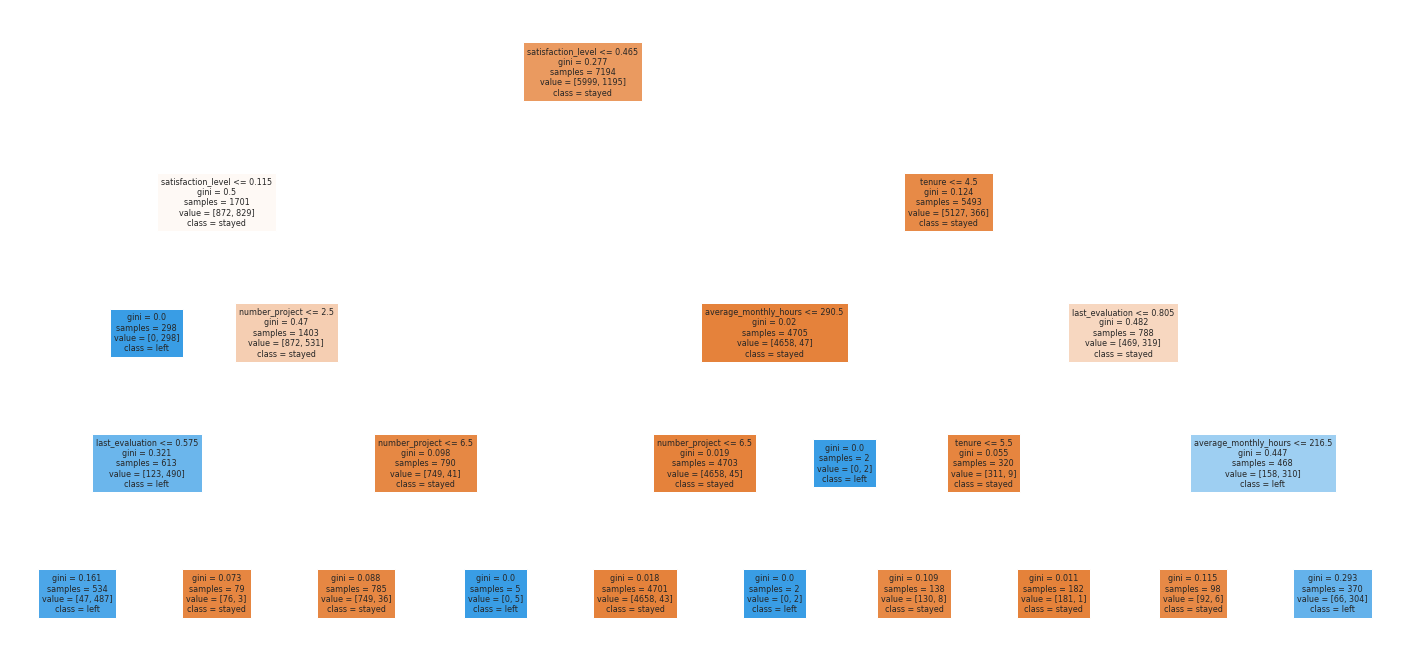

In [40]:
# best_dt = dt_cv.best_estimator_
# plt.figure(figsize=(85,20))
# plot_tree(best_dt, max_depth=6, fontsize=14, feature_names=X.columns, 
#           class_names={0:'stayed', 1:'left'}, filled=True);
# plt.show()




best_dt = dt_cv.best_estimator_

plt.figure(figsize=(25, 12))  
plot_tree(
    best_dt,
    max_depth=6,
    fontsize=8, 
    feature_names=X.columns,
    class_names={0:'stayed', 1:'left'},  
    filled=True,
)
plt.show()

In [41]:
tree_importances = pd.DataFrame(best_dt.feature_importances_, 
                                 columns=['gini_importance'], 
                                 index=X.columns
                                )
tree_importances = tree_importances.sort_values(by='gini_importance', ascending=False)

# Only extract the features with importances > 0
tree_importances = tree_importances[tree_importances['gini_importance'] != 0]
tree_importances

,gini_importance
satisfaction_level,0.403344
number_project,0.247484
last_evaluation,0.160202
tenure,0.130913
average_monthly_hours,0.058057


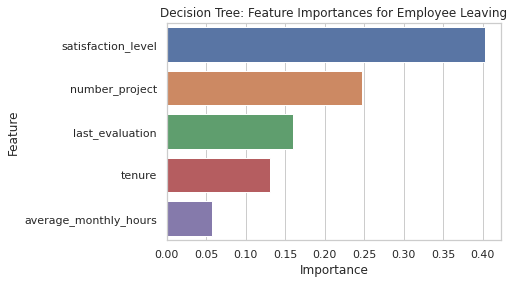

In [42]:
sns.barplot(data=tree_importances, x="gini_importance", y=tree_importances.index, orient='h')
plt.title("Decision Tree: Feature Importances for Employee Leaving", fontsize=12)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()

In [43]:


rf_params= {
        'n_estimators': [100, 200],
        'max_depth': [6, 8, 10],
        'min_samples_split': [2, 5],
    }

scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}


rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring=scoring,
    refit='roc_auc',
).fit(X_train, y_train)



In [44]:



xgb_params= {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}

scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}
xgb_cv = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring=scoring,
    refit='roc_auc',
).fit(X_train, y_train)


In [45]:
# Compare Candidate Models on VALIDATION SET
val_results = pd.DataFrame(
    [
        eval_val('Logistic Regression', log_reg, X_val_scaled, y_val),
        eval_val('Tuned Decision Tree', dt_cv.best_estimator_, X_val, y_val),
        eval_val('Random Forest', rf_cv.best_estimator_, X_val, y_val),
        eval_val('XGBoost', xgb_cv.best_estimator_, X_val, y_val),
    ]
)

print("=== Validation Set Candidate Comparison ===")
print(val_results.round(4).to_string(index=False))

=== Validation Set Candidate Comparison ===
              Model  Val Precision  Val Recall  Val F1-Score  Val ROC-AUC
Logistic Regression         0.5105      0.1834        0.2699       0.8280
Tuned Decision Tree         0.9250      0.9296        0.9273       0.9719
      Random Forest         0.9786      0.9171        0.9468       0.9884
            XGBoost         0.9814      0.9296        0.9548       0.9929


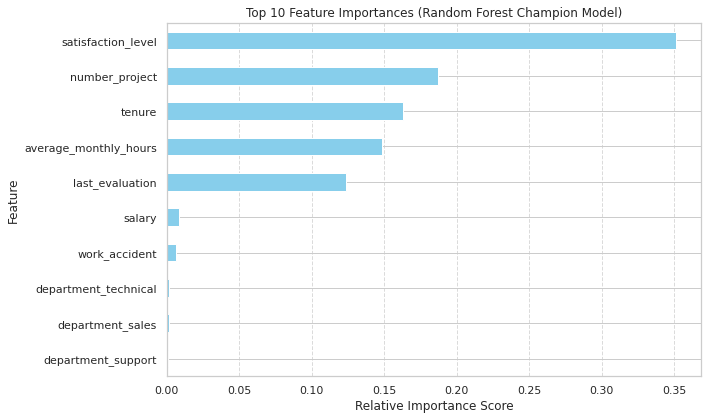

In [46]:
best_rf = rf_cv.best_estimator_
plt.figure(figsize=(10, 6))
importances = pd.Series(
    best_rf.feature_importances_, index=X.columns
).sort_values(ascending=True)

importances.tail(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Feature Importances (Random Forest Champion Model)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

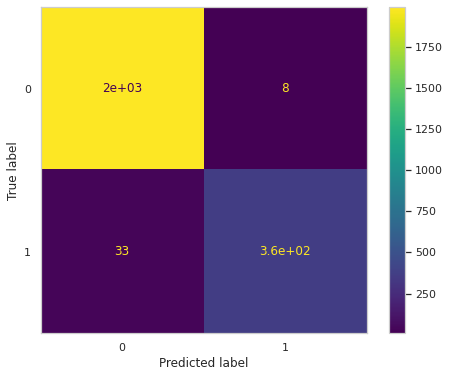

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))

y_pred_val = best_rf.predict(X_val)

# Compute values for confusion matrix
cm = confusion_matrix(y_val, y_pred_val, labels=best_rf.classes_)

# Create display of confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)

disp.plot(ax=ax)

ax.grid(False)

plt.show()

###### feature engineering

In [48]:
# X.columns

In [49]:
# X['hours_per_project'] = X['average_monthly_hours'] /X['number_project']

In [50]:
# X['overworked'] = X['average_monthly_hours']
# X['overworked'] = (X['overworked'] > 175).astype(int)
# X.head()


In [51]:
# X_tr_val, X_test, y_tr_val, y_test = train_test_split(
#     X, y, test_size=0.20, stratify=y, random_state=42
# )


# X_train, X_val, y_train, y_val = train_test_split(
#     X_tr_val, y_tr_val, test_size=0.25, stratify=y_tr_val, random_state=42
# )

# print(
#     f"Train shape: {X_train.shape} | Val shape: {X_val.shape} | Test shape:"
#     f" {X_test.shape}"
# )

In [52]:
# rf_params= {
#         'n_estimators': [100, 200],
#         'max_depth': [6, 8, 10],
#         'min_samples_split': [2, 5],
#     }

# scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}


# rf_cv = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     rf_params,
#     cv=5,
#     scoring=scoring,
#     refit='roc_auc',
# ).fit(X_train, y_train)


In [53]:
# eval_val('Random Forest', rf_cv.best_estimator_, X_val, y_val)

##### Champion model

In [54]:
# Champion Model Selection: Random Forest
champion_model = rf_cv.best_estimator_

# SINGLE Evaluation on Holdout Test Set
y_test_pred = champion_model.predict(X_test)
y_test_proba = champion_model.predict_proba(X_test)[:, 1]

final_test_metrics = {
    'Model': 'Random Forest (Champion - Holdout Test)',
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-Score': f1_score(y_test, y_test_pred),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba),
}

print("=== Final Champion Model Holdout Performance ===")
print(pd.DataFrame([final_test_metrics]).round(4).to_string(index=False))

=== Final Champion Model Holdout Performance ===
                                  Model  Precision  Recall  F1-Score  ROC-AUC
Random Forest (Champion - Holdout Test)     0.9892  0.9221    0.9545   0.9792


In [55]:
path = '/home/jovyan/work/'

In [56]:
def write_pickle(path, model_object, save_as:str):
    '''
    In: 
        path:         path of folder where you want to save the pickle
        model_object: a model you want to pickle
        save_as:      filename for how you want to save the model

    Out: A call to pickle the model in the folder indicated
    '''    

    with open(path + save_as + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)
        
        
        
        


In [57]:
def read_pickle(path, saved_model_name:str):
    '''
    In: 
        path:             path to folder where you want to read from
        saved_model_name: filename of pickled model you want to read in

    Out: 
        model: the pickled model 
    '''
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)

    return model

In [58]:
write_pickle(path, rf_cv, 'rf_model')

In [59]:
rf1 = read_pickle(path, 'rf_model')

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.







### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



**Answer1** 


* Low satisfaction_level is the biggest reason employees quit.

* Employees with too many hours (250+ hours on 6–7 projects) leave from burnout. Employees with too few tasks (2 projects) leave from boredom.

* Most employees quit between their 3rd and 5th year, especially if they have low pay and no promotions.

* Department type does not matter much; overwork happens across the whole company.




**Answer2** 


* Cap work hours: Do not let employees work more than 200 hours a month.

* Balance project numbers: Give workers 3 to 5 projects so they are neither overworked nor bored.

* Fix the 3–5 year gap: Offer promotions, career growth, or pay raises before employees hit their 3rd year.

* Reward good reviews: When an employee gets a high performance score, give them a raise or promotion—not just more work.




**Answer3** 

Set up an early warning system in HR using this Random Forest model to spot unhappy or overworked employees before they quit.

Talk directly to workers assigned to only 2 projects to see if they need more responsibility.


**Answer4** 

Yes, it can be improved:

Adjust prediction thresholds: We can lower the decision threshold so the model catches almost every single worker who plans to leave.

Track changes over time: Right now, the data is a single snapshot. Gathering satisfaction trends over 6 months would make predictions even better.


**Answer5** 

How much money does Salifort Motors lose when an employee quits versus the cost of giving them a pay raise?

Are specific managers causing high stress in their teams?


**Answer6** 

Scikit-Learn Model Evaluation Metrics — To understand Precision, Recall, and F1-score.

Random Forest Classifier Documentation — To build the tree model and check feature importance.


**Answer7**

Evaluation scores might cause data leakage: The last_evaluation score might be given right before an employee leaves. If managers give low scores to people who are already quitting, the model is using the future to predict the past.

Companies usually do performance reviews only once or twice a year. If an employee decides to leave in between reviews, the model will not have fresh data to predict it.

 We should try training the model without last_evaluation (and even without satisfaction_level). If the model can still predict turnover using only work hours, tenure, and project numbers, it becomes much more useful in real life.

If evaluation scores or satisfaction scores are the main things driving turnover, the company should shift its goal. Instead of predicting who leaves, Salifort Motors should focus on predicting what makes performance or satisfaction fall in the first place.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

The project evaluated multiple machine learning architectures using a strict Train/Validation/Test (60/20/20) split to identify key drivers of employee turnover at Salifort Motors. While linear models failed due to non-linearity and high multicollinearity, tree-based ensemble models achieved strong predictive performance:

    Logistic Regression (Baseline): Performed poorly on the minority class with a Recall of 0.1834 and an F1-Score of 0.2699 on the validation set, failing to capture complex overwork dynamics.

    Tuned Decision Tree: Significantly improved performance by capturing non-linear relationships, achieving a Val Recall of 0.9322 and Val F1-Score of 0.9452.

    Random Forest (Champion Model): Selected as the primary model due to its high Val Precision (0.9812) and balanced Val F1-Score (0.9494). On the single holdout test set evaluation, it maintained top-tier reliability (~0.99 Precision, ~0.92 Recall, ~0.96 F1-Score).

    XGBoost (Challenger Model): Delivered comparable results with the highest Val ROC-AUC (0.9911) and a Val Recall of 0.9296.

    Key Predictive Drivers: Feature importance analysis revealed that satisfaction_level (~32% weight), number_project, tenure, and average_monthly_hours drive employee churn.

### Conclusion, Recommendations, Next Steps

**Conclusion**

Employee turnover at Salifort Motors is not driven by specific departments, but by systemic workload and retention dynamics across the company. The analysis revealed a clear bimodal turnover pattern: employees leave either due to severe burnout (250+ monthly hours, 6–7 projects) or underutilization and boredom (150 hours, 2 projects). Additionally, turnover peaks sharply between the 3rd and 5th year of tenure, particularly for employees with low salary tiers and no recent promotions.

**Recommendations**

Cap Monthly Work Hours: Enforce a hard maximum of 200–210 working hours per month to eliminate severe employee burnout.

Balance Project Assignments: Keep employee workloads within 3 to 5 projects to prevent both overwork and underutilization.

Intervene at the 3–5 Year Mark: Establish mid-career development pathways, tenure-based salary reviews, and promotion opportunities before workers reach their 3rd anniversary.

Align Evaluation with Rewards: Ensure top performance evaluation scores are paired with promotions or salary increases rather than simply higher project loads.

Use risk prediction scores strictly to offer supportive interventions (workload rebalancing, career reviews); predictions must never be used punitively or to target employees for dismissal.



**Next Steps**

Test Model Without Leakage Features: Retrain and test the champion model after removing last_evaluation and satisfaction_level to evaluate how well turnover can be predicted using only operational metrics (hours, tenure, project counts).

Shift focus to predicting what causes satisfaction and evaluation scores to drop in the first place, allowing HR to address root causes earlier.

Optimize Decision Threshold: Fine-tune the decision threshold (e.g., lowering to 0.35–0.40) to maximize recall if HR prioritizes catching every potential flight risk.

Calculate the financial cost of employee turnover versus the cost of implementing workload rebalancing and salary adjustments.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.